In [1]:
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Optional GPU acceleration (RAPIDS)
GPU_AVAILABLE = False
GPU_BACKEND = 'CPU (scikit-learn)'
cp = None
cuPCA = None
try:
    import cupy as cp
    from cuml.decomposition import PCA as cuPCA
    GPU_AVAILABLE = True
    GPU_BACKEND = 'GPU (RAPIDS cuML)'
except Exception:
    pass

# Local utilities
import sys
sys.path.insert(0, '.')

random_state = 0

from pathlib import Path
MAIN_DIR = Path().resolve().parent.parent
PATH_DATA = MAIN_DIR / 'data' / 'processed'

In [2]:

df = pd.read_csv(PATH_DATA / 'train.csv')
print(f'Compute backend: {GPU_BACKEND}')
if not GPU_AVAILABLE:
    print('GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.')

Compute backend: CPU (scikit-learn)
GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.


## Advanced Analysis: Outliers & Distributions

Top 20 features by outlier count (IQR):
                      IQR  Z-score (>3)
mordred_BCUTdv-1h    1714           133
mordred_VSA_EState9  1644            94
VSA_EState9          1644            94
mordred_MINsssCH     1576            84
mordred_MAXsssCH     1576            69
mordred_SsssCH       1576            59
mordred_BCUTv-1l     1407           248
mordred_BCUTp-1l     1285           238
mordred_AATSC8c      1278            82
mordred_JGI10        1270            77
mordred_GGI10        1270            57
mordred_ATSC8c       1259           117
mordred_AATSC8s      1245            88
mordred_nHRing       1233            75
mordred_BCUTs-1h     1207             0
mordred_AATSC8Z      1192            56
mordred_MINsCl       1190             0
mordred_nCl          1190           125
mordred_NsCl         1190           125
mordred_MAXsCl       1190             0

Target (LD50) outliers (|z| > 3): 38


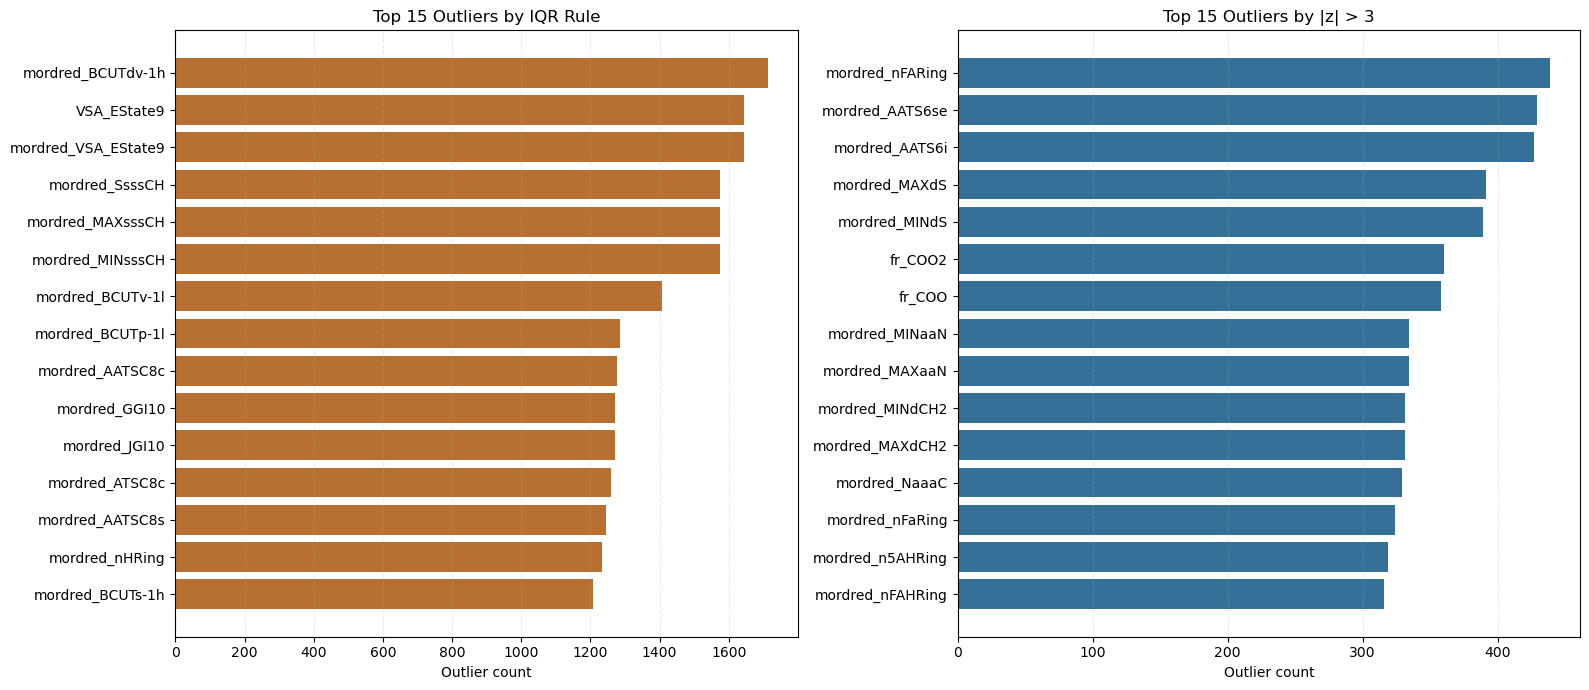

In [3]:
# Outlier detection
from scipy.stats import zscore

descriptor_cols = df.select_dtypes(include=[np.number]).columns.difference(['Y'])

outlier_summary = {}
for col in descriptor_cols:
    valid_data = df[col].dropna()

    # IQR method
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_outliers = ((valid_data < lower) | (valid_data > upper)).sum()

    # Z-score method (|z| > 3)
    z_scores = np.abs(zscore(valid_data))
    z_outliers = (z_scores > 3).sum()

    outlier_summary[col] = {'IQR': iqr_outliers, 'Z-score (>3)': z_outliers}

outlier_df = pd.DataFrame(outlier_summary).T
print('Top 20 features by outlier count (IQR):')
print(outlier_df.sort_values('IQR', ascending=False).head(20))
print(f"\nTarget (LD50) outliers (|z| > 3): {(np.abs(zscore(df['Y'])) > 3).sum()}")

# Visualization
top_n = 15
top_iqr = outlier_df.sort_values('IQR', ascending=False).head(top_n).sort_values('IQR')
top_z = outlier_df.sort_values('Z-score (>3)', ascending=False).head(top_n).sort_values('Z-score (>3)')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top_iqr.index, top_iqr['IQR'], color='#af601a', alpha=0.9)
axes[0].set_title(f'Top {top_n} Outliers by IQR Rule')
axes[0].set_xlabel('Outlier count')
axes[0].grid(alpha=0.25, axis='x', linestyle='--')

axes[1].barh(top_z.index, top_z['Z-score (>3)'], color='#1f618d', alpha=0.9)
axes[1].set_title(f'Top {top_n} Outliers by |z| > 3')
axes[1].set_xlabel('Outlier count')
axes[1].grid(alpha=0.25, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

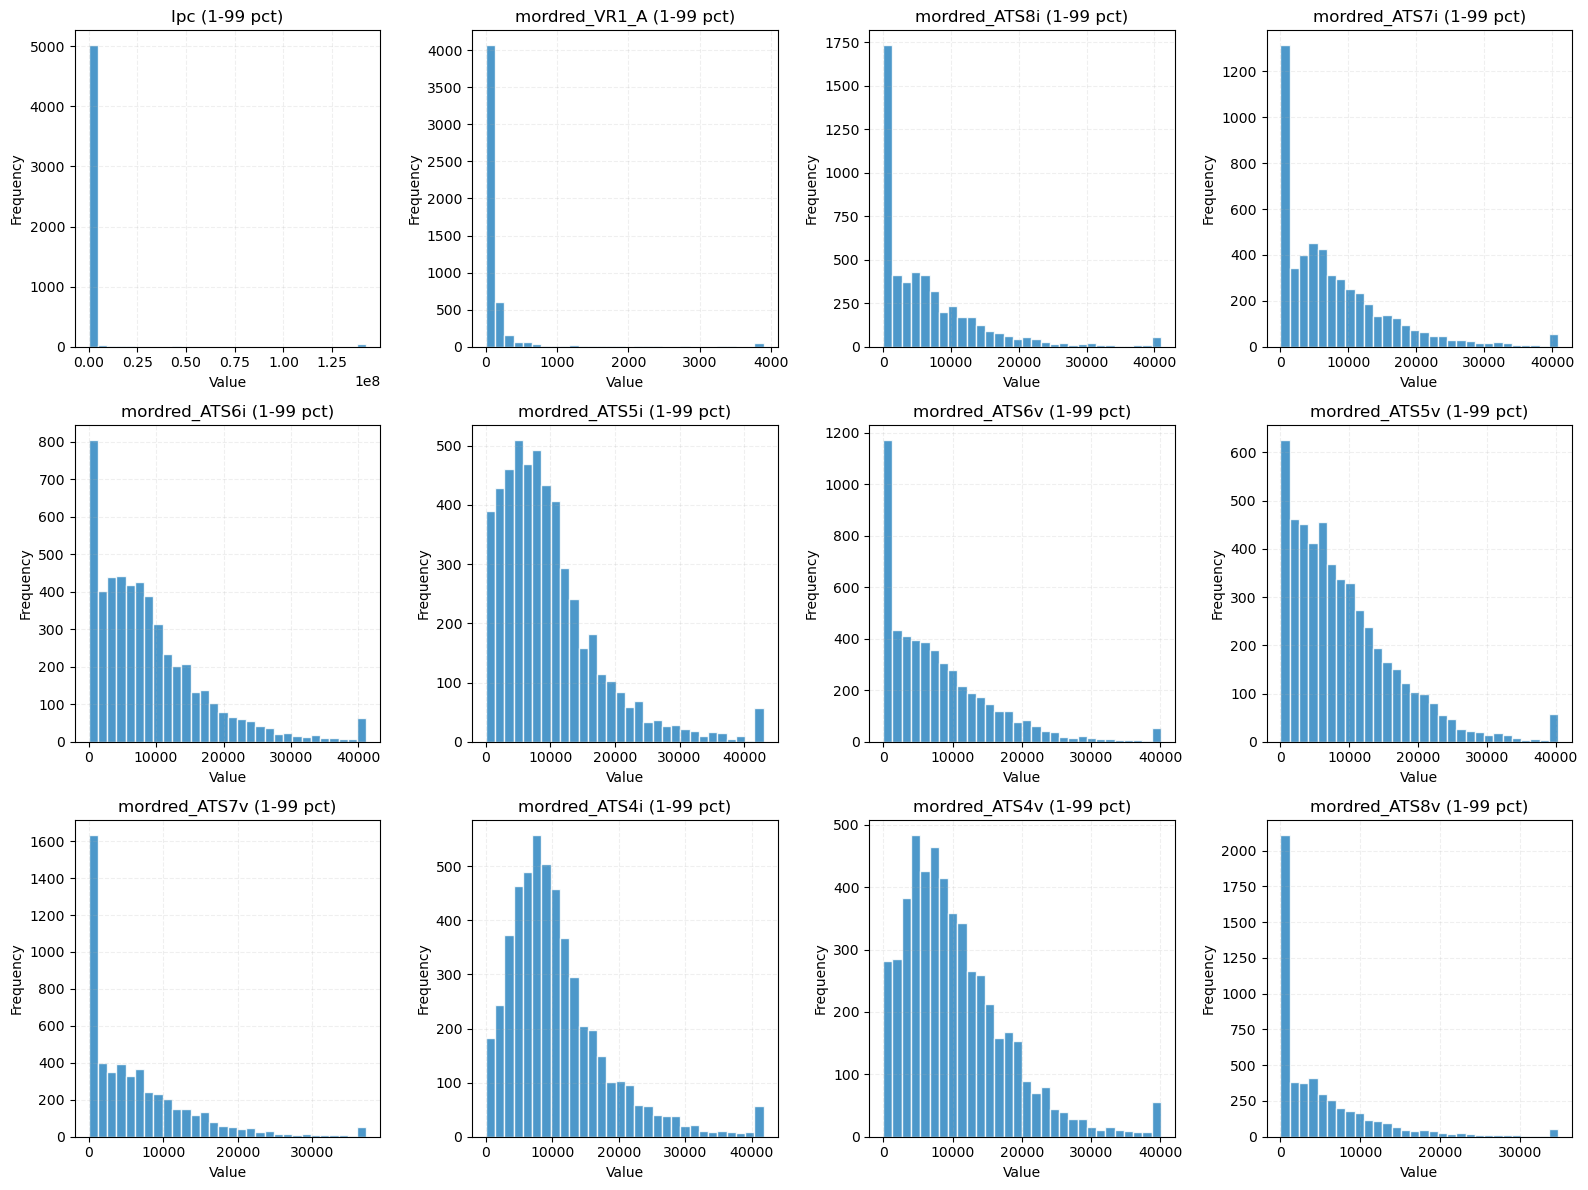


Descriptor summary (first 20 columns):
       BalabanJ   BertzCT      Chi0     Chi0n     Chi0v      Chi1     Chi1n  \
count  5169.000  5169.000  5169.000  5169.000  5169.000  5169.000  5169.000   
mean      2.871   344.913    11.347     8.878     9.747     7.144     4.880   
std       0.764   279.366     5.263     4.378     4.570     3.519     2.677   
min       0.826     2.000     2.000     1.115     1.115     1.000     0.289   
25%       2.331   134.107     7.707     5.847     6.444     4.715     3.071   
50%       2.829   289.906    10.552     8.197     9.047     6.630     4.444   
75%       3.266   471.711    14.044    11.023    12.368     8.987     6.070   
max       7.930  3416.975    66.977    56.065    56.065    42.102    30.562   

          Chi1v     Chi2n     Chi2v     Chi3n     Chi3v     Chi4n     Chi4v  \
count  5169.000  5169.000  5169.000  5169.000  5169.000  5169.000  5169.000   
mean      5.797     3.466     4.654     2.172     3.127     1.377     2.077   
std       3

In [4]:
# Feature distributions (readable histograms, clipped to 1st-99th percentile)
max_plots = 12
plot_cols = df[descriptor_cols].var().sort_values(ascending=False).head(max_plots).index.tolist()
n_rows, n_cols = 3, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(plot_cols):
    valid_data = df[col].dropna()
    low_q, high_q = np.percentile(valid_data, [1, 99])
    clipped = valid_data.clip(lower=low_q, upper=high_q)

    axes[idx].hist(clipped, bins=30, color='#2e86c1', alpha=0.85, edgecolor='white')
    axes[idx].set_title(f'{col} (1-99 pct)')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.2, linestyle='--')

for idx in range(len(plot_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Summary statistics
print('\nDescriptor summary (first 20 columns):')
print(df[descriptor_cols].describe().round(3).iloc[:, :20])

Top 20 features by |CV|:
                     Mean     Std       CV (%)      Min      Max     Range
mordred_AATSC6d    -0.000   0.162   -57717.219   -1.728    1.860     3.588
mordred_AATSC7p    -0.000   0.117   -30985.532   -1.305    2.115     3.420
mordred_ATSC6se    -0.009   1.474   -17218.805  -26.393   19.839    46.232
mordred_MATS8s     -0.003   0.386   -13926.654   -2.579    9.080    11.659
mordred_AATSC8pe   -0.000   0.059   -13555.615   -0.441    0.616     1.057
mordred_AATSC8are  -0.001   0.060   -11754.212   -0.498    0.666     1.164
mordred_AATSC7v    -0.168  16.932   -10078.667 -109.426  185.176   294.602
mordred_AATSC8s    -0.015   1.201    -8070.792   -8.471   20.510    28.982
mordred_n12FaHRing  0.000   0.014     7189.576    0.000    1.000     1.000
mordred_AATSC8dv    0.018   1.556     8774.344  -10.526   12.809    23.335
mordred_AATSC5c     0.000   0.007     9975.621   -0.109    0.095     0.204
mordred_MATS5c      0.001   0.230    15739.028   -1.910    3.979     5.889


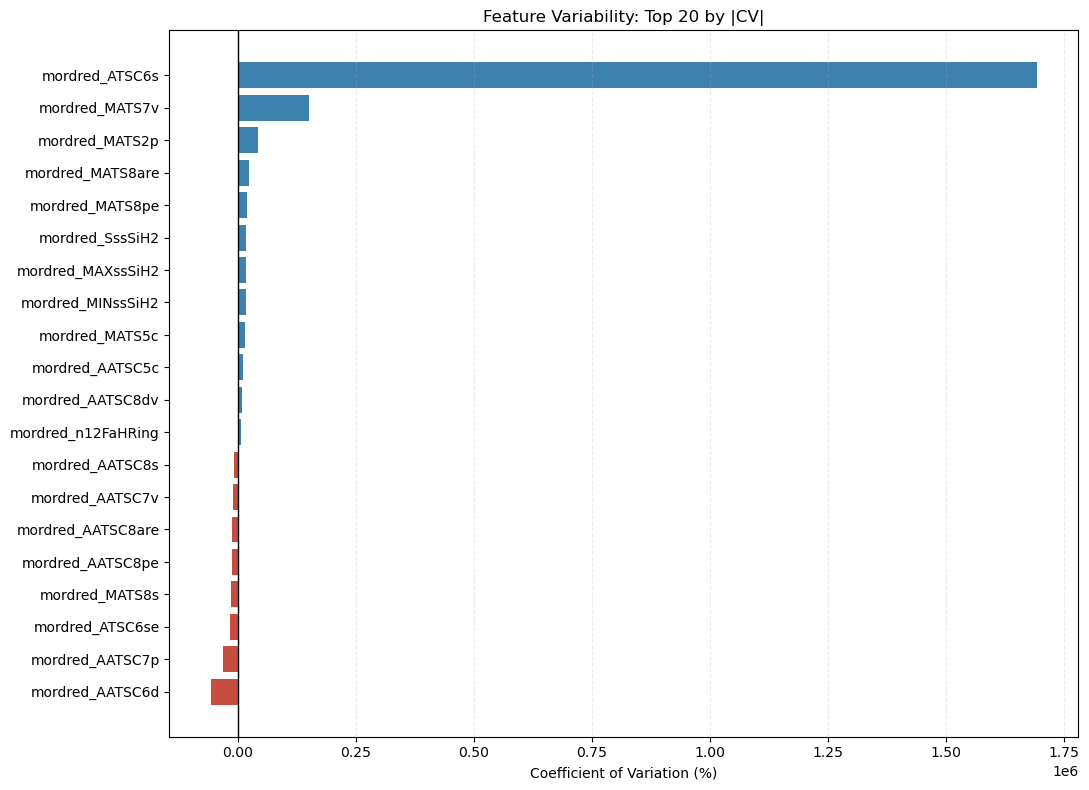

In [5]:
# Feature variability: Coefficient of Variation
cv_analysis = {}
for col in descriptor_cols:
    valid_data = df[col].dropna()
    mean_val = valid_data.mean()
    std_val = valid_data.std()
    cv = (std_val / mean_val) * 100 if mean_val != 0 else np.nan
    cv_analysis[col] = {
        'Mean': mean_val,
        'Std': std_val,
        'CV (%)': cv,
        'Min': valid_data.min(),
        'Max': valid_data.max(),
        'Range': valid_data.max() - valid_data.min()
    }

cv_df = pd.DataFrame(cv_analysis).T
cv_plot_df = cv_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['CV (%)']).copy()
cv_plot_df['Abs_CV'] = cv_plot_df['CV (%)'].abs()

top_n = 20
top_cv = cv_plot_df.nlargest(top_n, 'Abs_CV').sort_values('CV (%)')

print('Top 20 features by |CV|:')
print(top_cv[['Mean', 'Std', 'CV (%)', 'Min', 'Max', 'Range']].round(3))

# Visualization: only top |CV| features
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    top_cv.index,
    top_cv['CV (%)'],
    color=['#c0392b' if x < 0 else '#2874a6' for x in top_cv['CV (%)']],
    alpha=0.9
)
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title(f'Feature Variability: Top {top_n} by |CV|')
ax.axvline(0, color='black', linewidth=1)
ax.grid(alpha=0.25, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

In [6]:
# Prepare data for PCA
X = df[descriptor_cols].fillna(df[descriptor_cols].mean())
y = df['Y']

PCA refit without dominant feature: Ipc


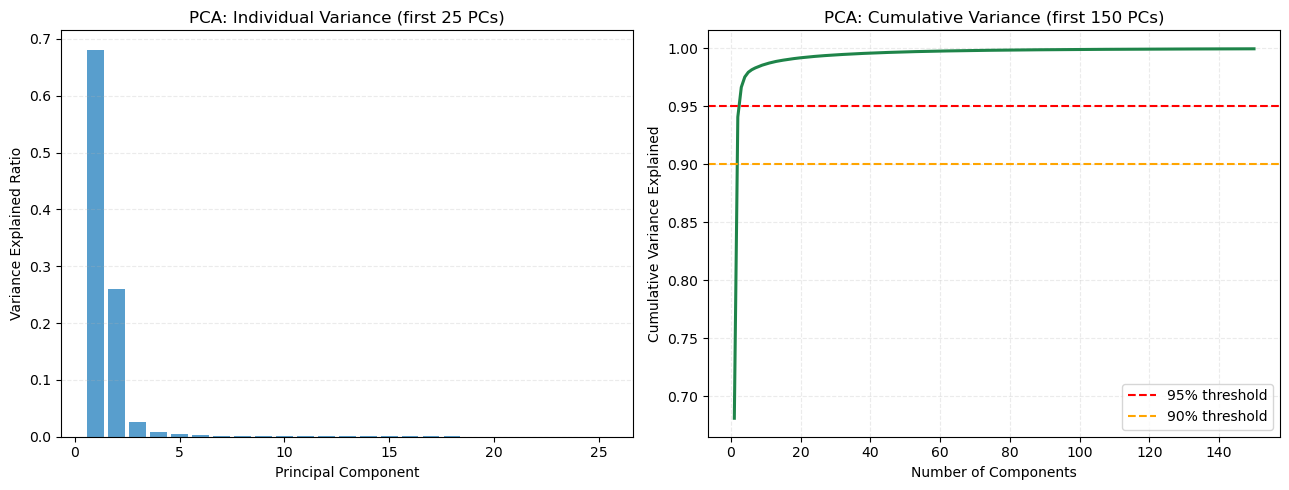

Components needed for 95% variance: 3/1810
Variance explained by first 3 PCs: 0.966


In [7]:
# PCA: Dimensionality reduction & variance analysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

# Standardize data
scaler = RobustScaler()
pca_feature_names = X.columns.copy()
X_pca_input = X.copy()
X_scaled = scaler.fit_transform(X_pca_input)

def fit_pca(x_scaled):
    if GPU_AVAILABLE and cuPCA is not None:
        x_gpu = cp.asarray(x_scaled, dtype=cp.float32)
        pca_model = cuPCA()
        pca_model.fit(x_gpu)
        return pca_model, cp.asnumpy(pca_model.explained_variance_ratio_)
    pca_model = PCA()
    pca_model.fit(x_scaled)
    return pca_model, pca_model.explained_variance_ratio_

pca, explained_var_ratio = fit_pca(X_scaled)

# If one feature dominates almost all variance, refit without dominant variance feature for readable PCA plots
if float(explained_var_ratio[0]) > 0.95 and X.shape[1] > 2:
    dominant_feature = X.var().idxmax()
    pca_feature_names = X.columns.difference([dominant_feature])
    X_pca_input = X[pca_feature_names]
    X_scaled = scaler.fit_transform(X_pca_input)
    pca, explained_var_ratio = fit_pca(X_scaled)
    print(f'PCA refit without dominant feature: {dominant_feature}')

# Plot variance explained (limited components for readability)
cumsum_var = np.cumsum(explained_var_ratio)
n_show = min(25, len(explained_var_ratio))
n_cum = min(150, len(cumsum_var))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual variance (first n_show PCs)
axes[0].bar(range(1, n_show + 1), explained_var_ratio[:n_show], alpha=0.8, color='#2e86c1')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title(f'PCA: Individual Variance (first {n_show} PCs)')
axes[0].grid(alpha=0.25, axis='y', linestyle='--')

# Cumulative variance (first n_cum PCs)
axes[1].plot(range(1, n_cum + 1), cumsum_var[:n_cum], linewidth=2.2, color='#1e8449')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title(f'PCA: Cumulative Variance (first {n_cum} PCs)')
axes[1].legend()
axes[1].grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

# Components needed for 95% variance
n_comps_95 = int(np.argmax(cumsum_var >= 0.95) + 1)
idx_3 = min(2, len(cumsum_var) - 1)
print(f'Components needed for 95% variance: {n_comps_95}/{len(explained_var_ratio)}')
print(f'Variance explained by first 3 PCs: {cumsum_var[idx_3]:.3f}')

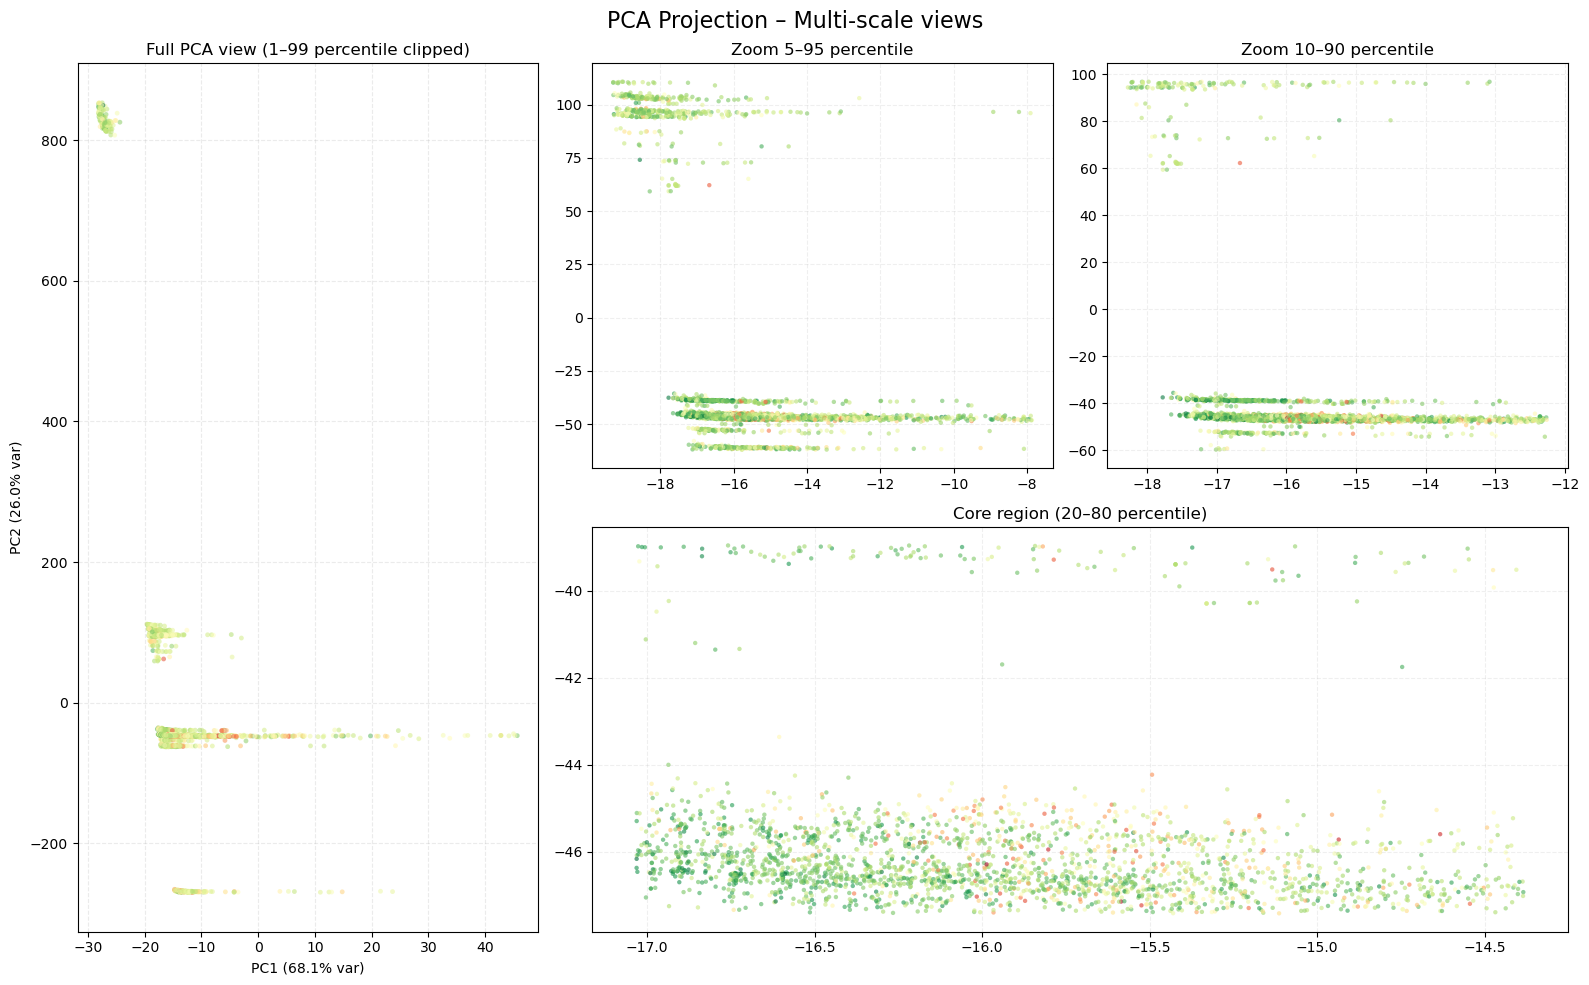


Top loading features for PC1/PC2:
                        PC1    PC2
mordred_VR1_A         0.788  0.010
mordred_VR2_A         0.615  0.008
mordred_BCUTv-1l     -0.012  0.988
mordred_BCUTdv-1h     0.003 -0.144
mordred_WPath         0.002 -0.001
mordred_MPC10         0.002 -0.001
mordred_fragCpx       0.002 -0.001
mordred_MPC9          0.001 -0.001
mordred_SpDiam_Dzm    0.001 -0.001
mordred_SpDiam_DzZ    0.001 -0.001
mordred_ETA_dAlpha_A -0.001  0.021
mordred_BCUTare-1h    0.000 -0.027
mordred_BCUTp-1l     -0.000  0.020
mordred_BCUTse-1h     0.000 -0.015
mordred_BCUTpe-1h     0.000 -0.017
mordred_SsF          -0.000 -0.012


In [8]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# =========================
# 2D PCA projection
# =========================

# Use first 2 PCs
if GPU_AVAILABLE and cuPCA is not None:
    # GPU path (CuPy)
    X_pca_full = pca.transform(cp.asarray(X_scaled, dtype=cp.float32))
    X_pca_2d = cp.asnumpy(X_pca_full)[:, :2]

    explained_1 = float(explained_var_ratio[0])
    explained_2 = float(explained_var_ratio[1])

    loadings = cp.asnumpy(pca.components_[:2, :]).T

else:
    # CPU path
    X_pca_2d = pca.transform(X_scaled)[:, :2]

    explained_1 = float(explained_var_ratio[0])
    explained_2 = float(explained_var_ratio[1])

    loadings = pca.components_[:2, :].T


# =========================
# DataFrame PCA
# =========================

pc_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Y': y.values
})

# Clip to 1st–99th percentile for a readable plot
pc1_low, pc1_high = np.percentile(pc_df['PC1'], [1, 99])
pc2_low, pc2_high = np.percentile(pc_df['PC2'], [1, 99])

vis_df = pc_df[
    (pc_df['PC1'] >= pc1_low) & (pc_df['PC1'] <= pc1_high) &
    (pc_df['PC2'] >= pc2_low) & (pc_df['PC2'] <= pc2_high)
]


# =========================
# Multi-subplot figure
# =========================

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig)

# === 1. Full view ===
ax1 = fig.add_subplot(gs[:, 0])
ax1.scatter(
    vis_df['PC1'],
    vis_df['PC2'],
    c=vis_df['Y'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.55,
    edgecolors='none'
)
ax1.set_xlabel(f'PC1 ({explained_1:.1%} var)')
ax1.set_ylabel(f'PC2 ({explained_2:.1%} var)')
ax1.set_title('Full PCA view (1–99 percentile clipped)')
ax1.grid(alpha=0.25, linestyle='--')


# === 2. Zoom 5–95 percentile ===
ax2 = fig.add_subplot(gs[0, 1])
zoom_95 = pc_df[
    (pc_df['PC1'].between(*np.percentile(pc_df['PC1'], [5, 95]))) &
    (pc_df['PC2'].between(*np.percentile(pc_df['PC2'], [5, 95])))
]

ax2.scatter(
    zoom_95['PC1'],
    zoom_95['PC2'],
    c=zoom_95['Y'],
    cmap='RdYlGn_r',
    s=10,
    alpha=0.6,
    edgecolors='none'
)
ax2.set_title("Zoom 5–95 percentile")
ax2.grid(alpha=0.2, linestyle='--')


# === 3. Zoom 10–90 percentile ===
ax3 = fig.add_subplot(gs[0, 2])
zoom_90 = pc_df[
    (pc_df['PC1'].between(*np.percentile(pc_df['PC1'], [10, 90]))) &
    (pc_df['PC2'].between(*np.percentile(pc_df['PC2'], [10, 90])))
]

ax3.scatter(
    zoom_90['PC1'],
    zoom_90['PC2'],
    c=zoom_90['Y'],
    cmap='RdYlGn_r',
    s=10,
    alpha=0.6,
    edgecolors='none'
)
ax3.set_title("Zoom 10–90 percentile")
ax3.grid(alpha=0.2, linestyle='--')


# === 4. Core region 20–80 percentile ===
ax4 = fig.add_subplot(gs[1, 1:])
zoom_80 = pc_df[
    (pc_df['PC1'].between(*np.percentile(pc_df['PC1'], [20, 80]))) &
    (pc_df['PC2'].between(*np.percentile(pc_df['PC2'], [20, 80])))
]

ax4.scatter(
    zoom_80['PC1'],
    zoom_80['PC2'],
    c=zoom_80['Y'],
    cmap='RdYlGn_r',
    s=10,
    alpha=0.6,
    edgecolors='none'
)
ax4.set_title("Core region (20–80 percentile)")
ax4.grid(alpha=0.2, linestyle='--')


# =========================
# Layout
# =========================

plt.suptitle("PCA Projection – Multi-scale views", fontsize=16)
plt.tight_layout()
plt.show()


# =========================
# Feature loading analysis
# =========================

loading_df = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=pca_feature_names)

top_pc1 = loading_df['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = loading_df['PC2'].abs().sort_values(ascending=False).head(10)

top_loadings = loading_df.loc[top_pc1.index.union(top_pc2.index)].copy()

print('\nTop loading features for PC1/PC2:')
print(top_loadings.sort_values('PC1', key=np.abs, ascending=False).round(3))

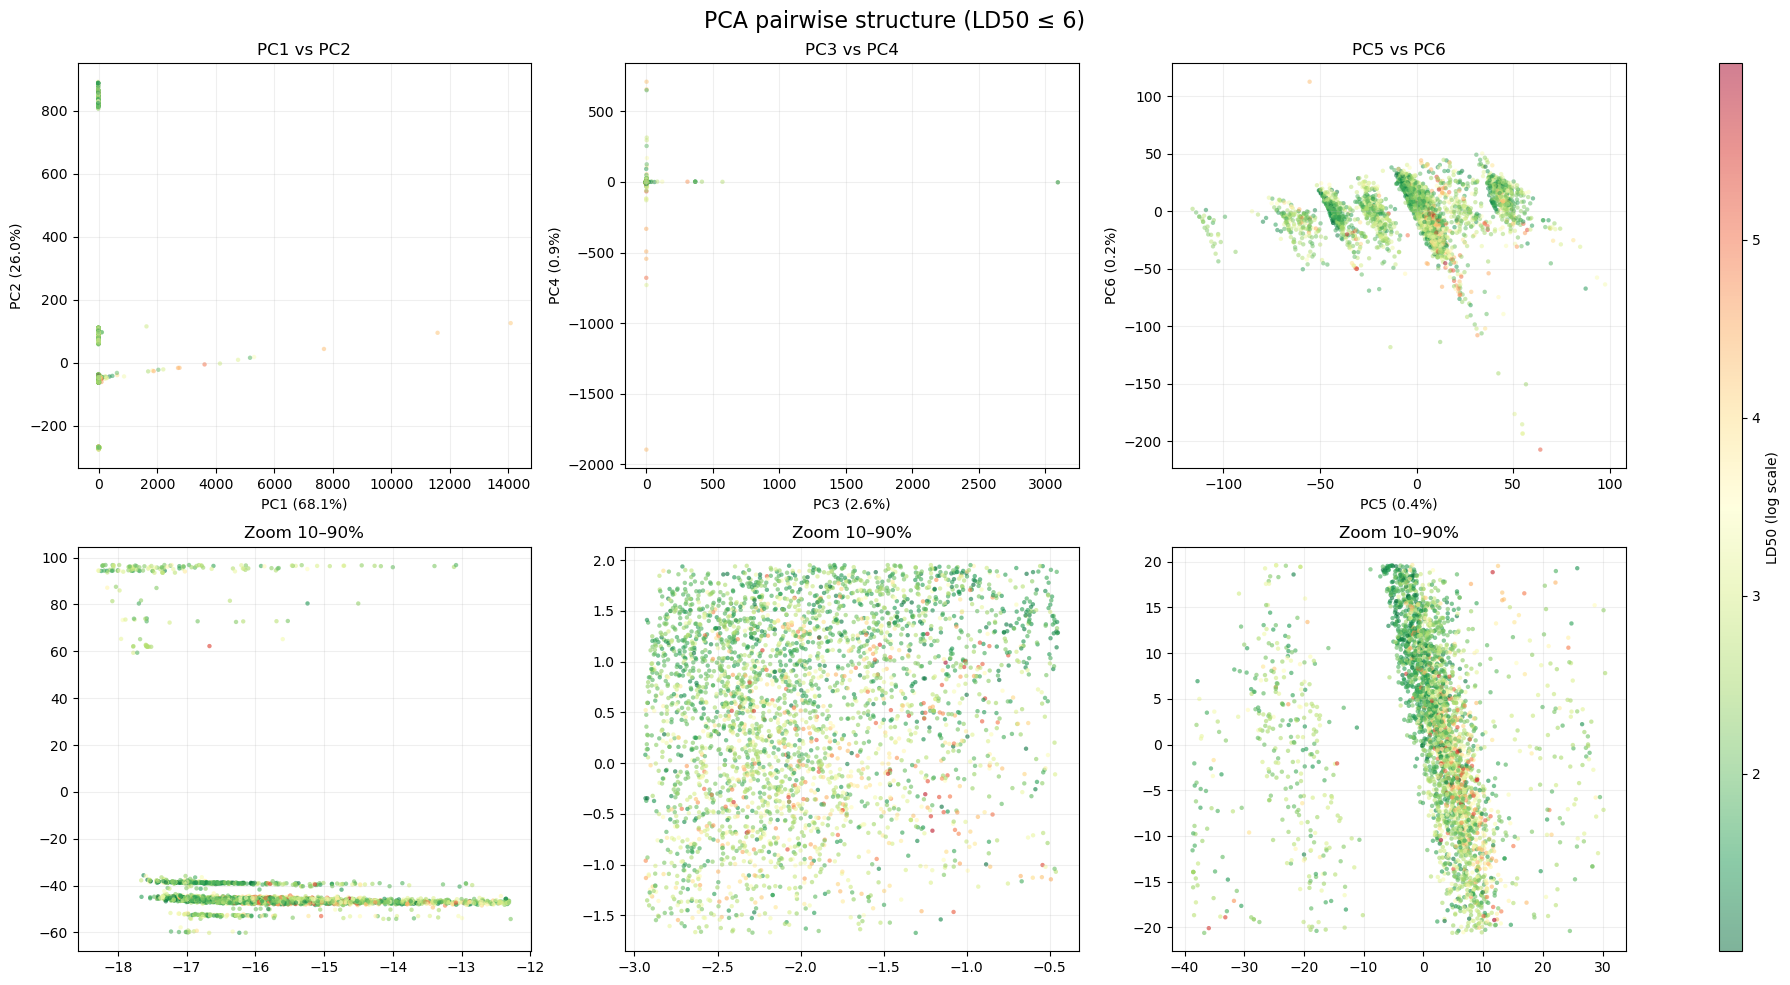

In [9]:
import matplotlib.pyplot as plt
import numpy as np

if GPU_AVAILABLE and cuPCA is not None:
    X_pca = cp.asnumpy(pca.transform(cp.asarray(X_scaled, dtype=cp.float32)))
else:
    X_pca = pca.transform(X_scaled)

y_vals = y.values
explained = pca.explained_variance_ratio_

pairs = [(0, 1), (2, 3), (4, 5)]

# =========================
# FILTER (remove > 6)
# =========================
mask_global = (y_vals <= 6) & (y_vals > 1)

X_pca_f = X_pca[mask_global]
y_f = y_vals[mask_global]


fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.05])

cmap = "RdYlGn_r"

sc = None

for i, (a, b) in enumerate(pairs):

    # ================= FULL
    ax = fig.add_subplot(gs[0, i])
    sc = ax.scatter(
        X_pca_f[:, a],
        X_pca_f[:, b],
        c=y_f,
        cmap=cmap,
        s=10,
        alpha=0.5,
        edgecolors='none'
    )

    ax.set_title(f"PC{a+1} vs PC{b+1}")
    ax.set_xlabel(f"PC{a+1} ({explained[a]:.1%})")
    ax.set_ylabel(f"PC{b+1} ({explained[b]:.1%})")
    ax.grid(alpha=0.2)

    # ================= ZOOM
    ax2 = fig.add_subplot(gs[1, i])

    x_low, x_high = np.percentile(X_pca_f[:, a], [10, 90])
    y_low, y_high = np.percentile(X_pca_f[:, b], [10, 90])

    mask_zoom = (
        (X_pca_f[:, a] >= x_low) & (X_pca_f[:, a] <= x_high) &
        (X_pca_f[:, b] >= y_low) & (X_pca_f[:, b] <= y_high)
    )

    ax2.scatter(
        X_pca_f[mask_zoom, a],
        X_pca_f[mask_zoom, b],
        c=y_f[mask_zoom],
        cmap=cmap,
        s=10,
        alpha=0.6,
        edgecolors='none'
    )

    ax2.set_title("Zoom 10–90%")
    ax2.grid(alpha=0.2)


# =========================
# Colorbar (outside)
# =========================

cax = fig.add_subplot(gs[:, 3])
cb = fig.colorbar(sc, cax=cax)
cb.set_label("LD50 (log scale)")

plt.suptitle("PCA pairwise structure (LD50 ≤ 6)", fontsize=16)
plt.tight_layout()
plt.show()

ANOVA top 20 most significant features (smallest p-values):
                  F-statistic        p-value
mordred_MIC1       437.307142  3.510145e-176
mordred_ATS1m      435.050395  2.420052e-175
mordred_ATS1Z      401.875610  6.065551e-163
mordred_SM1_DzZ    398.580999  1.051337e-161
mordred_Xp-3dv     398.255881  1.393383e-161
mordred_MIC2       398.246715  1.404492e-161
Chi3v              397.498791  2.685241e-161
mordred_SM1_Dzm    394.450782  3.773652e-160
mordred_NdsssP     384.201857  2.784853e-156
mordred_MINdsssP   376.316691  2.690557e-153
mordred_MAXdsssP   376.128208  3.171702e-153
mordred_nP         374.950092  8.871482e-153
mordred_ATSC1Z     371.475600  1.846920e-151
mordred_IC0        365.600058  3.159001e-149
mordred_ATSC1m     364.231311  1.048104e-148
mordred_Xp-2dv     363.546330  1.910532e-148
Chi2v              362.456339  4.968240e-148
mordred_ATS2Z      350.186057  2.393996e-143
mordred_GATS1m     345.356025  1.689929e-141
mordred_GATS1Z     344.955541  2.405995e

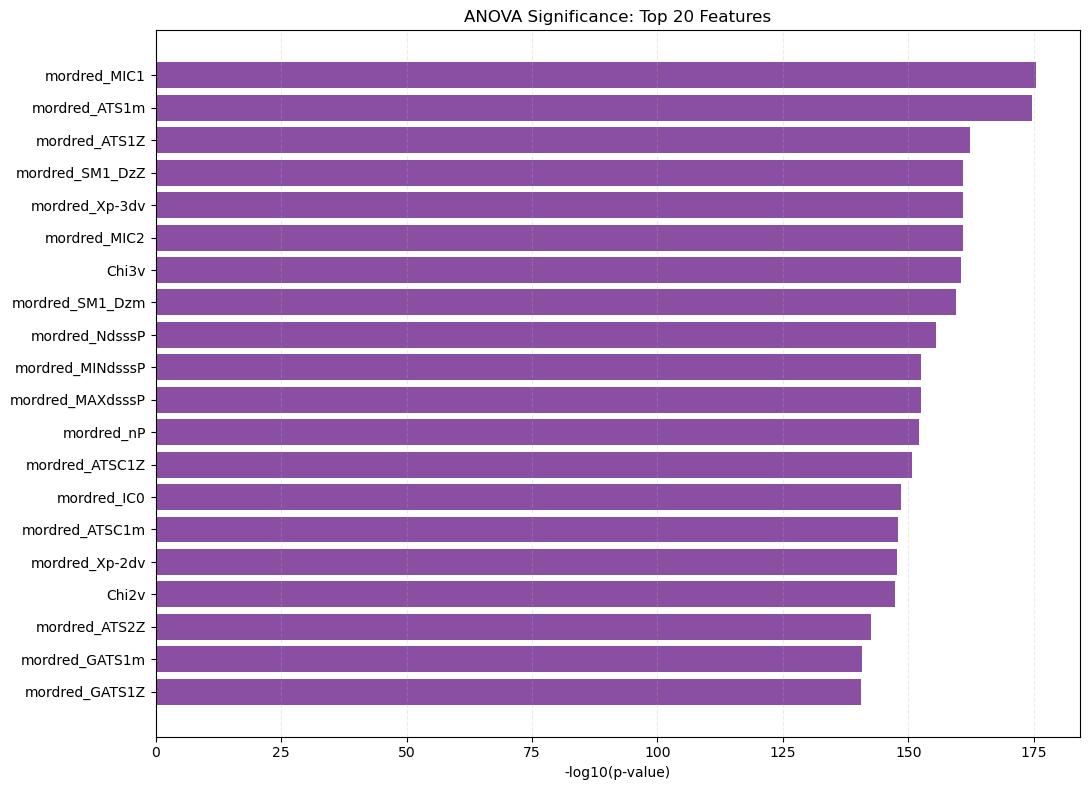

In [10]:
# ANOVA: Significance of features across toxicity groups
from scipy.stats import f_oneway, pearsonr

# Discretize target into 3 toxicity groups (low, medium, high)
y_groups = pd.qcut(df['Y'], q=3, labels=['Low', 'Medium', 'High'])

anova_results = {}
for col in descriptor_cols:
    valid_mask = df[col].notna()
    groups = [df[col][valid_mask & (y_groups == g)].values for g in ['Low', 'Medium', 'High']]

    # Remove empty groups
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = {'F-statistic': f_stat, 'p-value': p_val}

anova_df = pd.DataFrame(anova_results).T.sort_values('p-value', ascending=True)
significant = anova_df[anova_df['p-value'] < 0.05].copy()

print('ANOVA top 20 most significant features (smallest p-values):')
print(anova_df.head(20))
print(f"\nSignificant features (p < 0.05): {significant.shape[0]}")

if significant.shape[0] > 0:
    top_n = min(20, significant.shape[0])
    plot_df = significant.head(top_n).copy()
    plot_df['neg_log10_p'] = -np.log10(plot_df['p-value'].clip(lower=1e-300))
    plot_df = plot_df.sort_values('neg_log10_p')

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(plot_df.index, plot_df['neg_log10_p'], color='#7d3c98', alpha=0.9)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title(f'ANOVA Significance: Top {top_n} Features')
    ax.grid(alpha=0.25, axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()